In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import sys
import torch
import torchvision
from torchvision import datasets, models
from torchvision.transforms import functional as FT
from torchvision import transforms as T
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, sampler, random_split, Dataset
import copy
import math
from PIL import Image
import cv2
import albumentations as A  # our data augmentation library

import matplotlib.pyplot as plt
%matplotlib inline

# Custom modüller
sys.path.insert(0, "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/src")
from cb_loss import ClassBalancedDetectionClsLoss, compute_class_counts_from_coco
from training_logger import TrainingLogger

/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# remove arnings (optional)
import warnings
warnings.filterwarnings("ignore")
from collections import defaultdict, deque
import datetime
import time
from tqdm import tqdm # progress bar
from torchvision.utils import draw_bounding_boxes

In [4]:
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


PyCOCOTools provides many utilities for dealing with datasets in the COCO format, and if you wanted, you could evaluate the model's performance on the dataset with some of the utilities provided with this library.

That is out of scope for this notebook, however.

In [5]:
# our dataset is in cocoformat, we will need pypcoco tools
!pip install pycocotools
from pycocotools.coco import COCO

In [6]:
# Now, we will define our transforms
from albumentations.pytorch import ToTensorV2

In [7]:
def get_transforms(train=False):
    if train:
        transform = A.Compose([
            A.Resize(320, 320),
            A.HorizontalFlip(p=0.3),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco', clip=True))
    else:
        transform = A.Compose([
            A.Resize(320, 320),
            ToTensorV2()
        ], bbox_params=A.BboxParams(format='coco', clip=True))
    return transform

In [ ]:
class ThermalDetection(datasets.VisionDataset):
    def __init__(self, root, split='train', transform=None, target_transform=None, transforms=None):
        super().__init__(root, transforms, transform, target_transform)
        self.split = split
        self.coco = COCO(os.path.join(root, split, "_annotations.coco.json"))
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.ids = [id for id in self.ids if (len(self._load_target(id)) > 0)]

    def _load_image(self, id: int):
        # FIX (v4): Dataset'te 1-kanal gri, 3-kanal (R=G=B) ve ~%8 gercek renkli
        # (pseudo-color termal/RGB) goruntuler KARISIK. cv2.imread(default=IMREAD_COLOR)
        # 1-kanali 3'e kopyaliyor ama renkli dosyalari BGR olarak okuyordu ->
        # model iki farkli dagilim goruyordu (tum kanalar esit vs kanalar farkli).
        # Bu distribution shift test setinde asiri FP'ye yol aciyordu.
        # COZUM: Hepsini IMREAD_GRAYSCALE ile oku, sonra 3 ozdes kanala genislet.
        # Termal icerigi sadece intensity oldugu icin renkli 8%'de bilgi kaybi yok.
        path = self.coco.loadImgs(id)[0]['file_name']
        full = os.path.join(self.root, self.split, "images", path)
        img = cv2.imread(full, cv2.IMREAD_GRAYSCALE)
        if img is None:
            raise FileNotFoundError(full)
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    def _load_target(self, id):
        return self.coco.loadAnns(self.coco.getAnnIds(id))

    def __getitem__(self, index):
        id = self.ids[index]
        image = self._load_image(id)
        target = copy.deepcopy(self._load_target(id))

        boxes = [t['bbox'] + [t['category_id']] for t in target]
        if self.transforms is not None:
            transformed = self.transforms(image=image, bboxes=boxes)

        image = transformed['image']
        boxes = transformed['bboxes']

        # FIX (v4): Etiketleri donusum SONRASI kutulardan oku (box[4] = category_id).
        # Eski kod raw `target`'tan okuyordu; transform bir kutu dusurdugunde
        # label/kutu uyumsuzlugu olusuyordu. Su andaki transform'larla (Resize+HFlip,
        # clip=True) kutu dusmese de, ileride min_area/RandomCrop eklendiginde
        # sessizce yanlis egitime yol acardi.
        new_boxes = []
        new_labels = []
        for box in boxes:
            xmin = box[0]
            xmax = xmin + box[2]
            ymin = box[1]
            ymax = ymin + box[3]
            new_boxes.append([xmin, ymin, xmax, ymax])
            new_labels.append(int(box[4]) + 1)  # +1: 0=bg

        boxes = torch.tensor(new_boxes, dtype=torch.float32)

        targ = {}
        targ['boxes'] = boxes
        targ['labels'] = torch.tensor(new_labels, dtype=torch.int64)
        targ['image_id'] = torch.tensor([id])
        targ['area'] = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        targ['iscrowd'] = torch.zeros((len(new_labels),), dtype=torch.int64)
        return image.div(255), targ

    def __len__(self):
        return len(self.ids)

In [9]:
dataset_path = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/dataset/merged_thermal_coco_augmented"

In [10]:
#load classes
coco = COCO(os.path.join(dataset_path, "train", "_annotations.coco.json"))
categories = coco.cats
n_classes = len(categories.keys())
categories

loading annotations into memory...
Done (t=3.04s)
creating index...
index created!


{0: {'id': 0, 'name': 'Person', 'supercategory': 'none'},
 1: {'id': 1, 'name': 'Car', 'supercategory': 'none'},
 2: {'id': 2, 'name': 'OtherVehicle', 'supercategory': 'none'}}

In [11]:
classes = ['__background__'] + [i[1]['name'] for i in categories.items()]
classes  # 0=background, 1=Person, 2=Car, 3=OtherVehicle

['__background__', 'Person', 'Car', 'OtherVehicle']

In [12]:
train_dataset = ThermalDetection(root=dataset_path, transforms=get_transforms(True))

loading annotations into memory...
Done (t=3.12s)
creating index...
index created!


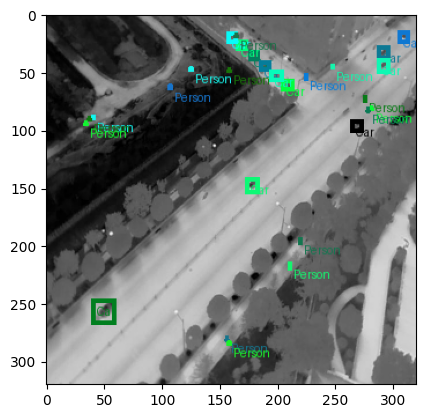

In [13]:
# Lets view a sample
sample = train_dataset[2]
img_int = torch.tensor(sample[0] * 255, dtype=torch.uint8)
plt.imshow(draw_bounding_boxes(
    img_int, sample[1]['boxes'], [classes[i] for i in sample[1]['labels']], width=4
).permute(1, 2, 0))

In [14]:
len(train_dataset)

62854

## Model

Our model is FasterRCNN with a backbone of `MobileNetV3-Large` (320px variant). This is the **lightest** Faster R-CNN in torchvision, optimized for edge/mobile devices.

Key advantages over ResNet50 backbone:
- ~10x fewer parameters (~19M vs ~41M)
- ~5x faster inference
- 320px min input size (vs 800px default)
- Designed for mobile/edge deployment

In [16]:
# En hafif Faster R-CNN: MobileNetV3-Large backbone, 320px input
model = models.detection.fasterrcnn_mobilenet_v3_large_320_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = models.detection.faster_rcnn.FastRCNNPredictor(in_features, n_classes + 1)

# FIX: Backbone'u baslangicta donduruyoruz (ilk 5 epoch sadece yeni head egitilir).
# NEDEN: Yeni eklenen box_predictor rastgele agirlikla basliyor. Bu ilk epoch'larda
# buyuk gradientler uretir ve geri yayilimla backbone'un onceden egitilmis
# ImageNet ozelliklerini BOZAR. Onceki egitimde loss_box'un 0.09'dan 0.30'a firlamasi
# tam olarak bu instability'nin isaretiydi. Ilk birkac epoch donmus backbone ile
# sadece head'i isinduruyoruz, sonra full fine-tune aciyoruz.
for p in model.backbone.parameters():
    p.requires_grad = False


This is our collating function for the train dataloader, it allows us to create batches of data that can be easily pass into the model

In [17]:
def collate_fn(batch):
    return tuple(zip(*batch))

In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, collate_fn=collate_fn)

The following blocks ensures that the model can take in the data and that it will not crash during training

In [19]:
images,targets = next(iter(train_loader))
images = list(image for image in images)
targets = [{k:v for k, v in t.items()} for t in targets]
output = model(images, targets) # just make sure this runs without error

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [21]:
model = model.to(device)

## Optimizer

Here, we define the optimizer. If you wish, you can also define the LR Scheduler, but it is not necessary for this notebook since our dataset is so small.

> Note, there are a few bugs with the current way `lr_scheduler` is implemented. If you wish to use the scheduler, you will have to fix those bugs

In [ ]:
# Optimizer
# FIX (v3): Param groups. Backbone LR head'in 1/10'u.
# NEDEN: v2'de backbone epoch 5'te acildiginda loss_box 0.03 -> 0.26'ya
# patlamisti (gradient instability). Tek bir LR ile backbone + head ayni
# hizda guncellenmeye zorlaniyordu; pretrained backbone icin bu hem asiri
# buyuk hem de destabilize edici. Param groups ile head=0.005, backbone=0.0005
# olarak ayarliyoruz; backbone frozen oldugu surece bu LR bir sey yapmaz,
# unfreeze sonrasi yumusak bir fine-tune saglar.
backbone_params = list(model.backbone.parameters())
backbone_ids = {id(p) for p in backbone_params}
head_params = [p for p in model.parameters() if id(p) not in backbone_ids]

optimizer = torch.optim.SGD(
    [
        {"params": head_params,     "lr": 0.005},
        {"params": backbone_params, "lr": 0.0005},
    ],
    momentum=0.9,
    nesterov=True,
    weight_decay=1e-4,
)

# Learning Rate Scheduler - cosine annealing (her param group orantili olcekler)
num_epochs = 150
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

# Mixed Precision
scaler = torch.amp.GradScaler('cuda')

# FIX (v4): save_dir artik faster_cnn4
save_dir = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn4"
os.makedirs(save_dir, exist_ok=True)

# Validation dataset
val_dataset = ThermalDetection(root=dataset_path, split="test", transforms=get_transforms(False))
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2, collate_fn=collate_fn)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

# Training Logger
logger = TrainingLogger(
    output_path=os.path.join(save_dir, "fasterrcnn_mobilenet_training.xlsx"),
    model_name="FasterRCNN-MobileNetV3-Large-320",
)
print(f"Weights -> {save_dir}")
print(f"Logger  -> {logger.output_path}")


loading annotations into memory...
Done (t=0.14s)
creating index...
index created!
Train: 62854 | Val: 2387
Weights -> /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn4
Logger  -> /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn4/fasterrcnn_mobilenet_training.xlsx


In [ ]:
import torchvision.models.detection.roi_heads as roi_heads

# COCO annotation'dan otomatik sinif sayilari
class_names_cb, class_counts_cb = compute_class_counts_from_coco(
    os.path.join(dataset_path, "train", "_annotations.coco.json")
)
print("Sinif sayilari (foreground):")
for name, count in zip(class_names_cb, class_counts_cb):
    print(f"  {name:15s}: {count}")

# FIX (v3): CB Loss background handling - Option A.
# ONCEKI HATA: v1/v2'de background_idx=0 verilmisti. cb_loss.py bu durumda
# background ROI'lerini forward() icinde loss'tan TAMAMEN dusuruyor. Ama
# Faster R-CNN'in fg/bg sampler'i her batch'te ~%75 bg ROI uretir; bunlar
# loss'a girmeyince model "bu arka plan" sinyalini hic almaz -> false
# positive'leri reddetmeyi ogrenemez.
#
# COZUM: background_idx=None kullan, class_counts listesinin basina
# bg_count ekle. bg_count = 3 * sum(fg).
bg_count = 3 * sum(class_counts_cb)
class_counts_with_bg = [bg_count] + list(class_counts_cb)
print(f"\nCB Loss icin sinif sayilari (background dahil):")
print(f"  background     : {bg_count}  (= 3 * sum(fg))")
for name, count in zip(class_names_cb, class_counts_cb):
    print(f"  {name:15s}: {count}")

# FIX (v4): beta 0.9999 -> 0.999.
# NEDEN: beta=0.9999 + buyuk class_counts (~300K-2.8M) ile effective_num
# formulu tum siniflarda ~10000'e saturate oluyordu; normalizasyon sonrasi
# weight'ler ~[1.0, 1.0, 1.0, 1.03] -> pratikte siradan focal loss, sinif
# dengeleme YOK. Ki datasette 36K OtherVehicle vs 577K Car var, gercek bir
# dengesizlik mevcut. beta=0.999 ile 36K icin effective_num ~972, 577K icin
# ~1000 -> belirgin weight farki olusur, OtherVehicle gercekten yukselir.
cb_cls_loss_fn = ClassBalancedDetectionClsLoss(
    class_counts=class_counts_with_bg,
    beta=0.999,
    gamma=2.0,
    loss_type="focal",
    background_idx=None,
    device=device,
)

# Faster R-CNN'in classification loss'unu CB Focal Loss ile degistir
def weighted_fastrcnn_loss(class_logits, box_regression, labels, regression_targets):
    labels = torch.cat(labels, dim=0)
    regression_targets = torch.cat(regression_targets, dim=0)

    # CB Focal Loss - artik tum ROI'ler (bg dahil) uzerinde
    classification_loss = cb_cls_loss_fn(class_logits, labels)

    sampled_pos_inds_subset = torch.where(labels > 0)[0]
    labels_pos = labels[sampled_pos_inds_subset]
    N, num_classes = class_logits.shape
    box_regression = box_regression.reshape(N, box_regression.size(-1) // 4, 4)

    box_loss = F.smooth_l1_loss(
        box_regression[sampled_pos_inds_subset, labels_pos],
        regression_targets[sampled_pos_inds_subset],
        beta=1 / 9,
        reduction="sum",
    )
    box_loss = box_loss / labels.numel()

    return classification_loss, box_loss

roi_heads.fastrcnn_loss = weighted_fastrcnn_loss
print("\nCB Focal Loss (background dahil, beta=0.999) ile weighted_fastrcnn_loss aktif!")

In [26]:
import sys

## Training

The following is a function that will train the model for one epoch. Torchvision Object Detections models have a loss function built in, and it will calculate the loss automatically if you pass in the `inputs` and `targets`

In [ ]:
def train_one_epoch(model, optimizer, loader, device, epoch, scaler):
    model.to(device)
    model.train()

    # Ilk epoch'ta warmup
    # NEDEN: LR'yi aniden 0.005'e vurmak yerine ilk 1000 iterasyonda
    # 5e-6 -> 0.005 araligina lineer yukseltiriz. Warmup olmadan yuksek LR
    # rastgele baslayan head'te gradient patlamasina yol acar.
    warmup_scheduler = None
    if epoch == 0:
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(loader) - 1)
        warmup_scheduler = optim.lr_scheduler.LinearLR(optimizer, start_factor=warmup_factor, total_iters=warmup_iters)

    all_losses = []
    all_losses_dict = []

    for images, targets in tqdm(loader):
        images = list(image.to(device) for image in images)
        # FIX (v3): torch.tensor(v) bir tensor uzerine cagrildiginda UserWarning
        # ve gereksiz kopya uretir. torch.as_tensor sifir-kopyali donusumdur.
        targets = [{k: torch.as_tensor(v).to(device) for k, v in t.items()} for t in targets]

        # Mixed Precision forward pass
        with torch.amp.autocast('cuda'):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        loss_dict_append = {k: v.item() for k, v in loss_dict.items()}
        loss_value = losses.item()

        all_losses.append(loss_value)
        all_losses_dict.append(loss_dict_append)

        if not math.isfinite(loss_value):
            print(f"Loss is {loss_value}, stopping training")
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad()
        scaler.scale(losses).backward()
        # FIX: Gradient clipping max_norm 5.0 -> 1.0 sikilastirildi.
        # NEDEN: Onceki egitimde loss_box oscilasyonu clip=5.0'in bu salinimi
        # engellemediini gosterdi. 1.0 standart guvenli deger; ozellikle MobileNet
        # gibi kucuk backbone'larda box regresyon gradientlerini zaptetmek kritik.
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        if warmup_scheduler is not None:
            warmup_scheduler.step()

    all_losses_dict = pd.DataFrame(all_losses_dict)
    avg_loss = np.mean(all_losses)

    # Ortalama loss bilesenleri
    avg_losses = {
        'loss_classifier': all_losses_dict['loss_classifier'].mean(),
        'loss_box_reg': all_losses_dict['loss_box_reg'].mean(),
        'loss_rpn_box_reg': all_losses_dict['loss_rpn_box_reg'].mean(),
        'loss_objectness': all_losses_dict['loss_objectness'].mean(),
    }

    print("Epoch {}, lr: {:.6f}, loss: {:.6f}, loss_classifier: {:.6f}, loss_box: {:.6f}, loss_rpn_box: {:.6f}, loss_object: {:.6f}".format(
        epoch, optimizer.param_groups[0]['lr'], avg_loss,
        avg_losses['loss_classifier'],
        avg_losses['loss_box_reg'],
        avg_losses['loss_rpn_box_reg'],
        avg_losses['loss_objectness']
    ))
    return avg_loss, avg_losses


In [ ]:
@torch.no_grad()
def evaluate(model, loader, device):
    """Val seti uzerinde loss + precision + recall + mAP hesaplar."""
    from torchvision.ops import box_iou

    # --- 1) Val loss (train mode ama BN eval'da) ---
    # FIX (v4): Faster R-CNN sadece train() modundayken loss dict dondurur.
    # Ama model.train() BatchNorm'un running_mean/var istatistiklerini val
    # verisi ile gunceller -> 115 epoch boyunca val BN stats'ini kirletir.
    # COZUM: modeli train()'e al, ardindan sadece BatchNorm katmanlarini
    # manuel olarak eval() moduna geri al. Boylece loss dondurulur ama
    # BN stats val'den etkilenmez.
    model.train()
    for m in model.modules():
        if isinstance(m, torch.nn.modules.batchnorm._BatchNorm):
            m.eval()

    loss_list = []
    for images, targets in loader:
        images = list(img.to(device) for img in images)
        tgts = [{k: v.to(device) for k, v in t.items()} for t in targets]
        with torch.amp.autocast('cuda'):
            ld = model(images, tgts)
        loss_list.append({k: v.item() for k, v in ld.items()})
    loss_df = pd.DataFrame(loss_list)

    # --- 2) Predictions (eval mode) ---
    model.eval()
    all_preds, all_gts = [], []
    for images, targets in loader:
        images = list(img.to(device) for img in images)
        with torch.amp.autocast('cuda'):
            preds = model(images)
        all_preds.extend([{k: v.cpu() for k, v in p.items()} for p in preds])
        all_gts.extend([{k: v.clone() for k, v in t.items()} for t in targets])

    # --- 3) Precision, Recall, Accuracy (IoU>=0.5, conf>0.5) ---
    tp, fp, fn, correct, total_det = 0, 0, 0, 0, 0
    for pred, gt in zip(all_preds, all_gts):
        keep = pred['scores'] > 0.5
        pb, pl = pred['boxes'][keep], pred['labels'][keep]
        gb, gl = gt['boxes'], gt['labels']
        total_det += len(pb)
        if len(pb) == 0:
            fn += len(gb); continue
        if len(gb) == 0:
            fp += len(pb); continue
        ious = box_iou(pb, gb)
        matched = set()
        for i in range(len(pb)):
            best_val, best_j = ious[i].max(0)
            j = best_j.item()
            if best_val >= 0.5 and j not in matched and pl[i] == gl[j]:
                tp += 1; correct += 1; matched.add(j)
            else:
                fp += 1
        fn += len(gb) - len(matched)

    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    acc  = correct / total_det if total_det > 0 else 0.0

    # --- 4) mAP (per-class AP, 101-point interpolation) ---
    fg_classes = list(range(1, n_classes + 1))

    def ap_at_iou(iou_t):
        aps = []
        for c in fg_classes:
            scores, matches, n_gt = [], [], 0
            for pred, gt in zip(all_preds, all_gts):
                gm = gt['labels'] == c
                n_gt += gm.sum().item()
                pm = pred['labels'] == c
                ps, pbox, gbox = pred['scores'][pm], pred['boxes'][pm], gt['boxes'][gm]
                if len(pbox) == 0: continue
                if len(gbox) == 0:
                    scores.extend(ps.tolist())
                    matches.extend([False] * len(ps))
                    continue
                iou = box_iou(pbox, gbox)
                used = set()
                for idx in ps.argsort(descending=True):
                    scores.append(ps[idx].item())
                    bv, bj = iou[idx].max(0)
                    j = bj.item()
                    if bv >= iou_t and j not in used:
                        matches.append(True); used.add(j)
                    else:
                        matches.append(False)
            if n_gt == 0: continue
            if not scores: aps.append(0.0); continue
            order = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)
            ms = [matches[i] for i in order]
            tp_c = np.cumsum(ms).astype(float)
            fp_c = np.cumsum([not m for m in ms]).astype(float)
            r = tp_c / n_gt
            p = tp_c / (tp_c + fp_c)
            ap = sum(p[r >= t].max() if (r >= t).any() else 0.0 for t in np.linspace(0, 1, 101)) / 101
            aps.append(ap)
        return np.mean(aps) if aps else 0.0

    m50 = ap_at_iou(0.5)
    m50_95 = np.mean([ap_at_iou(t) for t in np.arange(0.5, 1.0, 0.05)])

    return {
        'cls_loss': loss_df['loss_classifier'].mean(),
        'box_loss': loss_df['loss_box_reg'].mean() + loss_df['loss_rpn_box_reg'].mean(),
        'precision': prec,
        'recall': rec,
        'map50': m50,
        'map50_95': m50_95,
        'accuracy': acc,
    }

In [ ]:
# Checkpoint'tan devam etme + Egitim
resume_path = os.path.join(save_dir, 'last.pt')
start_epoch = 0

# FIX: best.pt artik loss yerine mAP50-95'e gore secilir.
# NEDEN: Onceki egitimde best.pt yalnizca epoch 1'de kaydedildi, cunku total loss
# bir daha 0.263'un altina inmedi (loss_box yapay sekilde artiyordu). Oysa gercek
# en iyi model epoch 119 civariydi. Detection'da loss ve mAP farkli yonlere gider;
# model seciminde her zaman dogru kriter mAP'tir.
best_map = -1.0

# FIX: Early stopping - mAP50-95 belli epoch boyunca iyilesmezse durur.
# NEDEN: Onceki egitim epoch 90'dan sonra plato'ya girdi; son 34 epoch (5+ saat)
# bosa harcandi. Patience=15 ile benzer israfi onluyoruz.
patience = 15
epochs_no_improve = 0

# FIX: Backbone'u ilk 5 epoch dondurulmus tutuyoruz (bkz. Cell 15), sonra aciyoruz.
UNFREEZE_EPOCH = 5

if os.path.exists(resume_path):
    print(f"Checkpoint bulundu: {resume_path}")
    checkpoint = torch.load(resume_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        lr_scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    if 'scaler_state_dict' in checkpoint:
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_map = checkpoint.get('best_map', -1.0)
    epochs_no_improve = checkpoint.get('epochs_no_improve', 0)
    # Devam ediliyorsa ve unfreeze epoch'u gectiysek backbone'u acik tut.
    if start_epoch >= UNFREEZE_EPOCH:
        for p in model.backbone.parameters():
            p.requires_grad = True
    print(f"Epoch {checkpoint['epoch']}'dan devam ediliyor (best mAP50-95: {best_map:.4f})")
else:
    print("Sifirdan baslaniyor.")

for epoch in range(start_epoch, num_epochs):
    # FIX: Belirlenen epoch'ta backbone fine-tune icin acilir.
    # NEDEN: Ilk birkac epoch head'i isindurduktan sonra backbone'un kendisi de
    # thermal domain'e adapte olmali (ImageNet RGB'ye gore egitilmisti).
    if epoch == UNFREEZE_EPOCH:
        for p in model.backbone.parameters():
            p.requires_grad = True
        print(f"[Epoch {epoch}] Backbone acildi (full fine-tune).")

    # --- Train ---
    avg_loss, avg_losses = train_one_epoch(model, optimizer, train_loader, device, epoch, scaler)
    lr_scheduler.step()

    # --- Eval (her epoch, tam val seti) ---
    print(f"  Eval ({len(val_dataset)} images)...")
    val = evaluate(model, val_loader, device)
    print(f"  Val -> cls:{val['cls_loss']:.4f} box:{val['box_loss']:.4f} "
          f"P:{val['precision']:.4f} R:{val['recall']:.4f} "
          f"mAP50:{val['map50']:.4f} mAP50-95:{val['map50_95']:.4f}")

    # --- Excel'e kaydet ---
    current_lr = optimizer.param_groups[0]['lr']
    logger.log_epoch(
        epoch=epoch,
        lr=current_lr,
        box_loss_train=avg_losses['loss_box_reg'] + avg_losses['loss_rpn_box_reg'],
        box_loss_val=val['box_loss'],
        cls_loss_train=avg_losses['loss_classifier'],
        cls_loss_val=val['cls_loss'],
        precision_val=val['precision'],
        recall_val=val['recall'],
        map50=val['map50'],
        map50_95=val['map50_95'],
        accuracy_val=val['accuracy'],
    )
    logger.save()

    # --- last.pt (her epoch, resume icin) ---
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': lr_scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict(),
        'loss': avg_loss,
        'best_map': best_map,
        'epochs_no_improve': epochs_no_improve,
    }, os.path.join(save_dir, 'last.pt'))

    # FIX: best.pt kriteri = mAP50-95 (loss yerine).
    if val['map50_95'] > best_map:
        best_map = val['map50_95']
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'map50_95': best_map,
            'map50': val['map50'],
        }, os.path.join(save_dir, 'best.pt'))
        print(f"  -> best.pt (mAP50-95: {best_map:.4f})")
    else:
        epochs_no_improve += 1
        print(f"  -> iyilesme yok ({epochs_no_improve}/{patience})")

    # FIX: Early stopping kontrolu.
    if epochs_no_improve >= patience:
        print(f"\nEarly stopping: mAP50-95 {patience} epoch boyunca iyilesmedi.")
        break

    print(f"  -> Epoch {epoch}/{num_epochs} | LR: {current_lr:.6f}")

logger.save()
print(f"\nEgitim tamamlandi! En iyi mAP50-95: {best_map:.4f}")
print(f"Metrikler: {logger.output_path}")


In [ ]:
# our learning rate was too low, due to a lr scheduler bug. For this task, we wont need a scheudul.er

## Trying on sample Images

This is the inference code for the model. First, we set the model to evaluation mode and clear the GPU Cache. We also load a test dataset, so that we can use fresh images that the model hasn't seen.

In [27]:
# we will watch first epoich to ensure no errrors
# while it is training, lets write code to see the models predictions. lets try again
model.eval()
torch.cuda.empty_cache()

In [28]:
test_dataset = ThermalDetection(root=dataset_path, split="test", transforms=get_transforms(False))

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!


In [29]:
img, _ = test_dataset[5]
img_int = torch.tensor(img*255, dtype=torch.uint8)
with torch.no_grad():
    prediction = model([img.to(device)])
    pred = prediction[0]

In [34]:
import sys
sys.path.append("/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection")

from src.plot_fasterrcnn_results import generate_all

# FIX (v4): yollar faster_cnn4
xlsx_path = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn4/fasterrcnn_mobilenet_training.xlsx"
out_dir = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster_cnn4"

generate_all(xlsx_path, out_dir)


FASTER R-CNN MOBILENET TRAINING RESULTS

Last Epoch (4):
  Box Loss    Train/Val: 1.8000 / 1.8500
  Class Loss  Train/Val: 3.4000 / 3.3000
  DFL Loss    Train/Val: 1.4500 / 1.4800
  Precision (Val): 0.6400
  Recall    (Val): 0.6800
  F1 Score  (Val): 0.6594
  mAP@0.5        : 0.2800
  mAP@0.5:0.95   : 0.1000
  Accuracy  (Val): nan

Best Values:
  mAP@0.5        : 0.2800 (Epoch 0)
  mAP@0.5:0.95   : 0.1000 (Epoch 0)
  Precision      : 0.6400 (Epoch 0)
  Recall         : 0.6800 (Epoch 0)
  F1             : 0.6594 (Epoch 0)
  Val Box Loss   : 1.8500 (Epoch 0)

Saved:
  - /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster_cnn4/results.png
  - /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster_cnn4/lr_schedule.png
  - /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster_cnn4/confusion_matrix.png


{'results': PosixPath('/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster_cnn4/results.png'),
 'lr': PosixPath('/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster_cnn4/lr_schedule.png'),
 'cm': PosixPath('/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/models/faster_cnn4/confusion_matrix.png')}

In [32]:
# ============================================================
# TEST: best.pt ile test setinde degerlendir, metrikleri xlsx'e yaz
# ============================================================
import openpyxl
from torchvision.ops import box_iou

# FIX (v4): yollar faster_cnn4
xlsx_path = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn4/fasterrcnn_mobilenet_training.xlsx"
best_ckpt = "/home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn4/best.pt"

# En iyi checkpoint'i yukle
ckpt = torch.load(best_ckpt, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device).eval()
# FIX (v3): v2'de best.pt loss yerine mAP50-95 ile kaydediliyor (Cell 30).
# Eski kod ckpt['loss']'u okuyordu -> her zaman nan basiyordu.
print(f"Yuklendi: best.pt (epoch {ckpt.get('epoch','?')}, mAP50-95 {ckpt.get('map50_95', float('nan')):.4f})")

# Sinif isimleri (Faster R-CNN: 0=background, 1..n_fg=classes)
fg_names = [categories[i]['name'] for i in sorted(categories.keys())]  # ['Person','Car','OtherVehicle']
cm_names = fg_names + ['background']
n_fg = len(fg_names)
cm_size = n_fg + 1

IOU_T, CONF_T = 0.5, 0.5

# Test loader
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False,
                         num_workers=2, collate_fn=collate_fn)

# Confusion matrix: satir=gercek sinif, sutun=tahmin. Son indeks=background
cm = np.zeros((cm_size, cm_size), dtype=np.int64)

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Test"):
        imgs = [im.to(device) for im in images]
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
        for pred, gt in zip(preds, targets):
            scores = pred['scores'].cpu()
            mask = scores > CONF_T
            p_boxes = pred['boxes'].cpu()[mask]
            p_labels = pred['labels'].cpu()[mask]
            p_scores = scores[mask]
            g_boxes = gt['boxes']
            g_labels = gt['labels']

            matched_gt, matched_pred = set(), set()
            if len(p_boxes) > 0 and len(g_boxes) > 0:
                ious = box_iou(p_boxes, g_boxes)
                order = torch.argsort(p_scores, descending=True).tolist()
                for pi in order:
                    best_val, best_j = ious[pi].max(0)
                    j = best_j.item()
                    if best_val >= IOU_T and j not in matched_gt:
                        gi = int(g_labels[j].item()) - 1
                        pj = int(p_labels[pi].item()) - 1
                        if 0 <= gi < n_fg and 0 <= pj < n_fg:
                            cm[gi, pj] += 1
                            matched_gt.add(j); matched_pred.add(pi)

            # Kacirilan GT'ler: Actual=class, Predicted=background
            for j in range(len(g_boxes)):
                if j not in matched_gt:
                    gi = int(g_labels[j].item()) - 1
                    if 0 <= gi < n_fg:
                        cm[gi, n_fg] += 1
            # Spurious / yanlis sinif: Actual=background, Predicted=class
            for pi in range(len(p_boxes)):
                if pi not in matched_pred:
                    pj = int(p_labels[pi].item()) - 1
                    if 0 <= pj < n_fg:
                        cm[n_fg, pj] += 1

# --- Metrikler ---
tp = np.array([cm[i, i] for i in range(n_fg)], dtype=np.int64)
fp = cm[:, :n_fg].sum(axis=0) - tp   # satirlar (background dahil) toplami - diagonal
fn = cm[:n_fg, :].sum(axis=1) - tp   # sutunlar (background dahil) toplami - diagonal

prec = tp / np.maximum(tp + fp, 1)
rec  = tp / np.maximum(tp + fn, 1)
f1   = 2 * prec * rec / np.maximum(prec + rec, 1e-12)

total_tp  = int(tp.sum())
total_gt  = int(cm[:n_fg, :].sum())
total_pr  = int(cm[:, :n_fg].sum())
accuracy  = total_tp / max(total_gt, 1)
macro_p   = float(prec.mean())
macro_r   = float(rec.mean())
macro_f1  = float(f1.mean())

print("\nConfusion Matrix (satir=gercek, sutun=tahmin):")
print(" " * 14 + " ".join(f"{n:>13}" for n in cm_names))
for i, name in enumerate(cm_names):
    print(f"{name:>13} " + " ".join(f"{v:>13d}" for v in cm[i]))

print(f"\nAccuracy       : {accuracy:.4f}")
print(f"Macro Precision: {macro_p:.4f}")
print(f"Macro Recall   : {macro_r:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")
for i, name in enumerate(fg_names):
    print(f"  {name:15s} P:{prec[i]:.4f}  R:{rec[i]:.4f}  F1:{f1[i]:.4f}  (TP:{tp[i]} FP:{fp[i]} FN:{fn[i]})")

# ============================================================
# Mevcut xlsx'e yaz (Confusion Matrix sheet + Test Results sheet)
# ============================================================
wb = openpyxl.load_workbook(xlsx_path)

# -- Confusion Matrix sheet --
ws_cm = wb["Confusion Matrix"]
for row in range(7, ws_cm.max_row + 5):
    for col in range(1, cm_size + 10):
        ws_cm.cell(row=row, column=col).value = None

ws_cm["B2"] = "Confusion Matrix \u2014 FasterRCNN-MobileNetV3-Large-320 (Test)"

header_row = 7
ws_cm.cell(row=header_row, column=3, value="Predicted \u2192")
for j, name in enumerate(cm_names):
    ws_cm.cell(row=header_row, column=4 + j, value=name)
ws_cm.cell(row=header_row + 1, column=2, value="Actual \u2193")

for i, name in enumerate(cm_names):
    r = header_row + 1 + i
    ws_cm.cell(row=r, column=3, value=name)
    for j in range(cm_size):
        ws_cm.cell(row=r, column=4 + j, value=int(cm[i, j]))

# Normalized CM (satir toplamina gore)
norm_start = header_row + cm_size + 3
ws_cm.cell(row=norm_start, column=3, value="Normalized Confusion Matrix (row %)")
ws_cm.cell(row=norm_start + 1, column=3, value="Actual \u2193")
for j, name in enumerate(cm_names):
    ws_cm.cell(row=norm_start + 1, column=4 + j, value=name)
for i, name in enumerate(cm_names):
    r = norm_start + 2 + i
    ws_cm.cell(row=r, column=3, value=name)
    row_sum = int(cm[i].sum())
    for j in range(cm_size):
        val = float(cm[i, j]) / row_sum if row_sum > 0 else 0.0
        ws_cm.cell(row=r, column=4 + j, value=round(val, 4))

# -- Test Results sheet --
if "Test Results" in wb.sheetnames:
    del wb["Test Results"]
ws_tr = wb.create_sheet("Test Results")
ws_tr["A1"] = "Metric"
ws_tr["B1"] = "Value"

summary = [
    ("Model",            "FasterRCNN-MobileNetV3-Large-320"),
    ("Checkpoint",       f"best.pt (epoch {ckpt.get('epoch','?')})"),
    ("Test images",      len(test_dataset)),
    ("IoU threshold",    IOU_T),
    ("Conf threshold",   CONF_T),
    ("Accuracy",         round(accuracy, 4)),
    ("Macro Precision",  round(macro_p, 4)),
    ("Macro Recall",     round(macro_r, 4)),
    ("Macro F1",         round(macro_f1, 4)),
    ("Total TP",         total_tp),
    ("Total GT",         total_gt),
    ("Total Predictions",total_pr),
]
for i, (k, v) in enumerate(summary, start=2):
    ws_tr.cell(row=i, column=1, value=k)
    ws_tr.cell(row=i, column=2, value=v)

# Per-class tablo
start = len(summary) + 4
headers = ["Class", "Precision", "Recall", "F1", "TP", "FP", "FN"]
for c, h in enumerate(headers, start=1):
    ws_tr.cell(row=start, column=c, value=h)
for i, name in enumerate(fg_names):
    r = start + 1 + i
    ws_tr.cell(row=r, column=1, value=name)
    ws_tr.cell(row=r, column=2, value=round(float(prec[i]), 4))
    ws_tr.cell(row=r, column=3, value=round(float(rec[i]),  4))
    ws_tr.cell(row=r, column=4, value=round(float(f1[i]),   4))
    ws_tr.cell(row=r, column=5, value=int(tp[i]))
    ws_tr.cell(row=r, column=6, value=int(fp[i]))
    ws_tr.cell(row=r, column=7, value=int(fn[i]))

wb.save(xlsx_path)
print(f"\nTest sonuclari xlsx'e kaydedildi: {xlsx_path}")


Yuklendi: best.pt (epoch 115, mAP50-95 0.1289)


Test: 100%|██████████| 299/299 [00:18<00:00, 16.00it/s]


Confusion Matrix (satir=gercek, sutun=tahmin):
                     Person           Car  OtherVehicle    background
       Person          4338             1             0         11913
          Car             3          8866             2         17219
 OtherVehicle             2            11          1042           412
   background         48915         36347          1842             0

Accuracy       : 0.3252
Macro Precision: 0.2128
Macro Recall   : 0.4390
Macro F1       : 0.2841
  Person          P:0.0815  R:0.2669  F1:0.1248  (TP:4338 FP:48920 FN:11914)
  Car             P:0.1960  R:0.3398  F1:0.2486  (TP:8866 FP:36359 FN:17224)
  OtherVehicle    P:0.3611  R:0.7103  F1:0.4788  (TP:1042 FP:1844 FN:425)

Test sonuclari xlsx'e kaydedildi: /home/atp-user-18/Desktop/uc_cihazlarda_terhmal_object_detection/runs/faster_cnn4/fasterrcnn_mobilenet_training.xlsx
